# NTSB Aviation Accident EDA (2008–2025)

**Author:** Miguel Restrepo

**Data:** NTSB Aviation Accident Database — `avall.mdb`

**Period covered:** 2008–2025

**Records analyzed:** ~18,500 accidents

## Research questions

1. Has the US aviation accident rate declined over time?
2. Which phase of flight concentrates the most accidents?
3. What are the most frequently cited contributing factors?
4. Does pilot age correlate with accident severity?
5. Are IMC accidents more lethal than VMC accidents?

---
*Note: this analysis covers accidents only — events where the NTSB
classification is `ACC`. Incidents (`INC`) are excluded.*

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import folium
from folium.plugins import HeatMap
import os
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

conn = sqlite3.connect("../data/aviation.db")

In [2]:
events   = pd.read_sql("SELECT * FROM events",          conn)
aircraft = pd.read_sql("SELECT * FROM aircraft",         conn)
findings = pd.read_sql("SELECT * FROM Findings",         conn)
crew     = pd.read_sql("SELECT * FROM Flight_Crew",      conn)
injury   = pd.read_sql("SELECT * FROM injury",           conn)
ev_seq   = pd.read_sql("SELECT * FROM Events_Sequence",  conn)

for name, df in [("events", events), ("aircraft", aircraft), ("findings", findings),
                 ("crew", crew), ("injury", injury), ("ev_seq", ev_seq)]:
    print(f"{name:<12} {len(df):>7,} rows  |  {df.shape[1]} columns")

events        30,212 rows  |  73 columns
aircraft      30,726 rows  |  93 columns
findings      70,874 rows  |  14 columns
crew          31,545 rows  |  33 columns
injury       173,347 rows  |  7 columns
ev_seq        64,642 rows  |  10 columns


### 1.1 Filter & type coercion

We restrict to accident records (`ev_type == 'ACC'`) from 2008 onward.
Earlier records exist in the database but reporting practices before 2008
are less consistent for minor incidents, which would distort trend analysis.

In [3]:
# Dates and coordinates
events["ev_date"]       = pd.to_datetime(events["ev_date"], errors="coerce")
events["ev_year"]       = pd.to_numeric(events["ev_year"],  errors="coerce")
events["ev_month"]      = pd.to_numeric(events["ev_month"], errors="coerce")
events["dec_latitude"]  = pd.to_numeric(events["dec_latitude"],  errors="coerce")
events["dec_longitude"] = pd.to_numeric(events["dec_longitude"], errors="coerce")

# Injury columns
for col in ["inj_tot_f", "inj_tot_s", "inj_tot_n", "inj_tot_t"]:
    events[col] = pd.to_numeric(events[col], errors="coerce").fillna(0).astype(int)

# Filter
events = events[
    (events["ev_type"] == "ACC") &
    (events["ev_year"] >= 2008)
].copy()

year_min = int(events["ev_year"].min())
year_max = int(events["ev_year"].max())
print(f"Accidents after filter: {len(events):,}")
print(f"Year range: {year_min} – {year_max}")

Accidents after filter: 27,998
Year range: 2008 – 2026


### 1.2 Missing data audit
Before any analysis, we check missingness in the columns we will use.
This prevents drawing conclusions from silently incomplete data.

In [4]:
key_cols = {
    "events":   ["ev_date", "ev_year", "dec_latitude", "dec_longitude",
                 "wx_cond_basic", "ev_highest_injury", "inj_tot_f"],
    "aircraft": ["damage", "acft_make", "acft_category", "acft_year"],
    "crew":     ["crew_age", "crew_inj_level"],
}

for table_name, cols in key_cols.items():
    df_ref = {"events": events, "aircraft": aircraft, "crew": crew}[table_name]
    total  = len(df_ref)
    print(f"\n{'─'*50}")
    print(f"  {table_name.upper()}  ({total:,} rows)")
    print(f"{'─'*50}")
    for col in cols:
        if col not in df_ref.columns:
            continue
        n_null = df_ref[col].isna().sum()
        pct    = n_null / total * 100
        bar    = "█" * int(pct / 5) + "░" * (20 - int(pct / 5))
        print(f"  {col:<28} {bar}  {pct:5.1f}%  ({n_null:,} missing)")


──────────────────────────────────────────────────
  EVENTS  (27,998 rows)
──────────────────────────────────────────────────
  ev_date                      ░░░░░░░░░░░░░░░░░░░░    0.0%  (0 missing)
  ev_year                      ░░░░░░░░░░░░░░░░░░░░    0.0%  (0 missing)
  dec_latitude                 █░░░░░░░░░░░░░░░░░░░    7.0%  (1,946 missing)
  dec_longitude                █░░░░░░░░░░░░░░░░░░░    6.9%  (1,944 missing)
  wx_cond_basic                ██░░░░░░░░░░░░░░░░░░   12.1%  (3,379 missing)
  ev_highest_injury            ░░░░░░░░░░░░░░░░░░░░    1.8%  (490 missing)
  inj_tot_f                    ░░░░░░░░░░░░░░░░░░░░    0.0%  (0 missing)

──────────────────────────────────────────────────
  AIRCRAFT  (30,726 rows)
──────────────────────────────────────────────────
  damage                       █░░░░░░░░░░░░░░░░░░░    6.7%  (2,066 missing)
  acft_make                    ░░░░░░░░░░░░░░░░░░░░    0.1%  (43 missing)
  acft_category                ░░░░░░░░░░░░░░░░░░░░    1.3%  (394 mi

## Question 1 — Has the accident rate declined over time?

We aggregate accidents and fatalities by year. Both series are plotted
together: bars for accident count (left axis), line for fatalities (right axis).

**Caveat:** 2026 data is partial it will appear artificially low. We flag it visually.

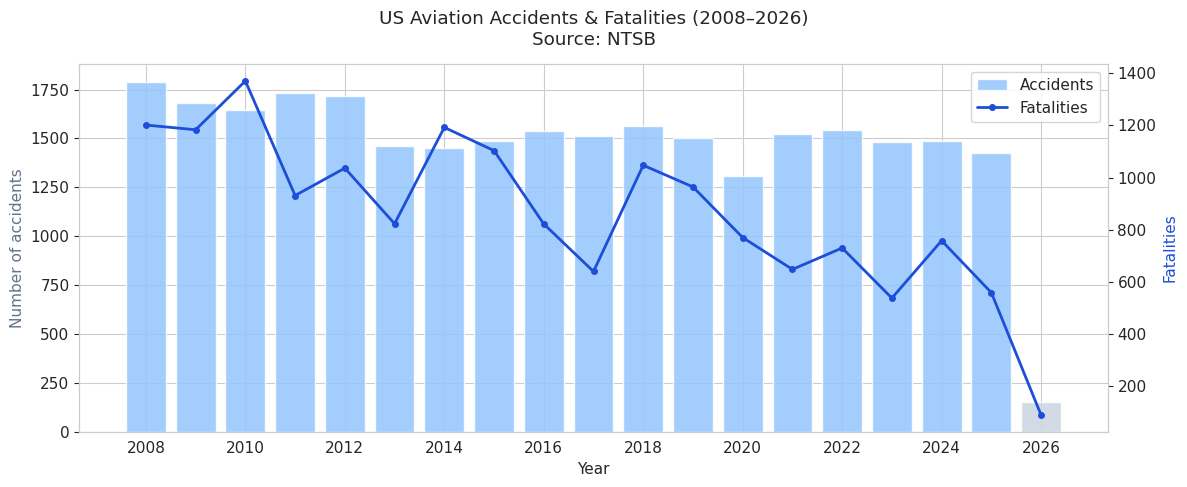

In [5]:
yearly = (
    events.groupby("ev_year")
    .agg(accidents=("ev_id", "count"), fatalities=("inj_tot_f", "sum"))
    .reset_index()
)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# Flag partial year
colors = ["#93C5FD" if y < year_max else "#CBD5E1" for y in yearly["ev_year"]]

ax1.bar(yearly["ev_year"], yearly["accidents"], color=colors, alpha=0.85, label="Accidents")
ax2.plot(yearly["ev_year"], yearly["fatalities"], color="#1D4ED8", linewidth=2,
         marker="o", markersize=4, label="Fatalities")

ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.xaxis.set_minor_locator(mticker.MultipleLocator(1))

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of accidents", color="#64748B")
ax2.set_ylabel("Fatalities", color="#1D4ED8")
ax1.set_title(f"US Aviation Accidents & Fatalities ({year_min}–{year_max})\nSource: NTSB", pad=14)
ax2.grid(False)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig("../charts/q1_trend.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Both accident counts and fatalities show a sustained decline
from 2008 through ~2019. The 2020 drop is amplified by reduced air traffic
during the COVID-19 pandemic. Post-2020 levels remain lower than the
2008–2015 baseline, suggesting a genuine improvement in safety outcomes —
though flight hour exposure data would be needed to confirm a true rate reduction.

The greyed-out 2026 bar is partial and excluded from trend interpretation.

## Question 2 — Which phase of flight is most dangerous?

We join `Events_Sequence` (which records the phase at which each occurrence
happened) with `events` to count accidents and average fatalities per phase.

**Note:** one accident can have multiple phase records — we count distinct
`ev_id` values to avoid double-counting accidents.

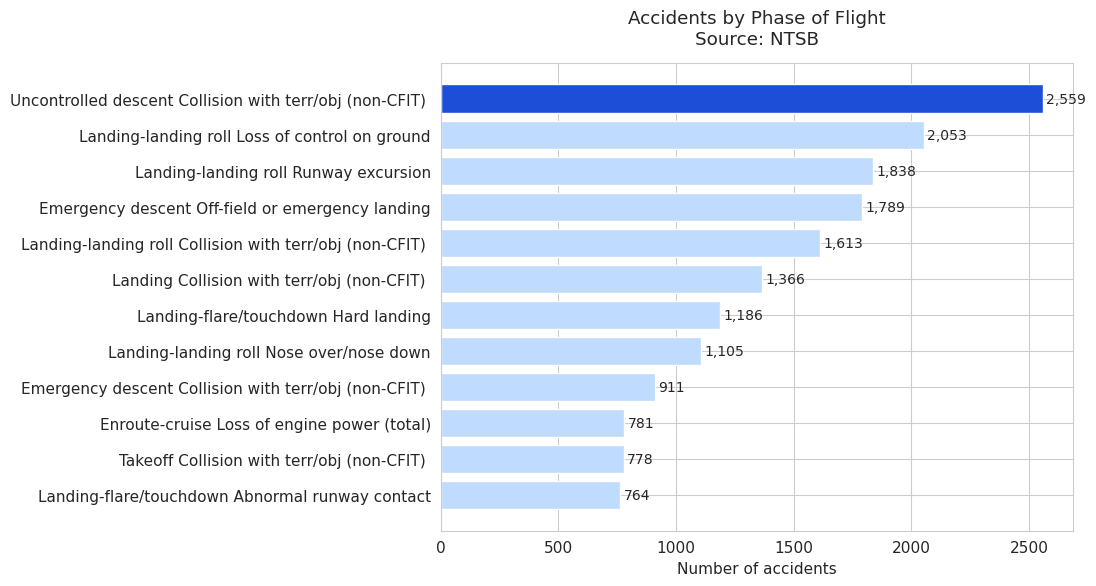

                                                   phase  accidents  fatalities  avg_fatalities
Uncontrolled descent Collision with terr/obj (non-CFIT)        2559        2742            1.07
          Landing-landing roll Loss of control on ground       2053          15            0.01
                   Landing-landing roll Runway excursion       1838          29            0.02
        Emergency descent Off-field or emergency landing       1789         213            0.12
Landing-landing roll Collision with terr/obj (non-CFIT)        1613          17            0.01
             Landing Collision with terr/obj (non-CFIT)        1366          92            0.07
                    Landing-flare/touchdown Hard landing       1186          22            0.02
                Landing-landing roll Nose over/nose down       1105          15            0.01
   Emergency descent Collision with terr/obj (non-CFIT)         911         269            0.29
             Enroute-cruise Loss of engi

In [6]:
phase_query = """
    SELECT
        es.Occurrence_Description        AS phase,
        COUNT(DISTINCT es.ev_id)         AS accidents,
        SUM(e.inj_tot_f)                 AS fatalities,
        ROUND(AVG(e.inj_tot_f), 2)       AS avg_fatalities
    FROM Events_Sequence es
    JOIN events e ON es.ev_id = e.ev_id
    WHERE es.Occurrence_Description IS NOT NULL
      AND es.Occurrence_Description != ''
      AND e.ev_type = 'ACC'
      AND e.ev_year >= 2008
    GROUP BY phase
    ORDER BY accidents DESC
    LIMIT 12
"""
df_phase = pd.read_sql(phase_query, conn)

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ["#1D4ED8" if i == 0 else "#BFDBFE" for i in range(len(df_phase))]
bars = ax.barh(df_phase["phase"], df_phase["accidents"], color=bar_colors)

for bar, val in zip(bars, df_phase["accidents"]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10)

ax.set_xlabel("Number of accidents")
ax.set_title("Accidents by Phase of Flight\nSource: NTSB", pad=14)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../charts/q2_phase.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_phase[["phase", "accidents", "fatalities", "avg_fatalities"]].to_string(index=False))

**Finding:** The most frequent accident category is **uncontrolled descent /
collision with terrain (non-CFIT)** — 2,559 accidents and the highest average
fatalities per event (1.07). Landing phases account for the next four spots
by volume, but with near-zero average fatalities (0.01–0.02), reflecting
low-speed ground incidents rather than fatal crashes.

The pattern is clear: landing accidents are frequent but survivable.
Loss of control in flight is rarer but almost always fatal.

## Question 3 — What are the most common contributing factors?

The `Findings` table contains structured NTSB cause codes with plain-text
descriptions. Each accident can have multiple findings (hence 70k rows for ~18,500 accidents).
We count finding occurrences across all accidents.

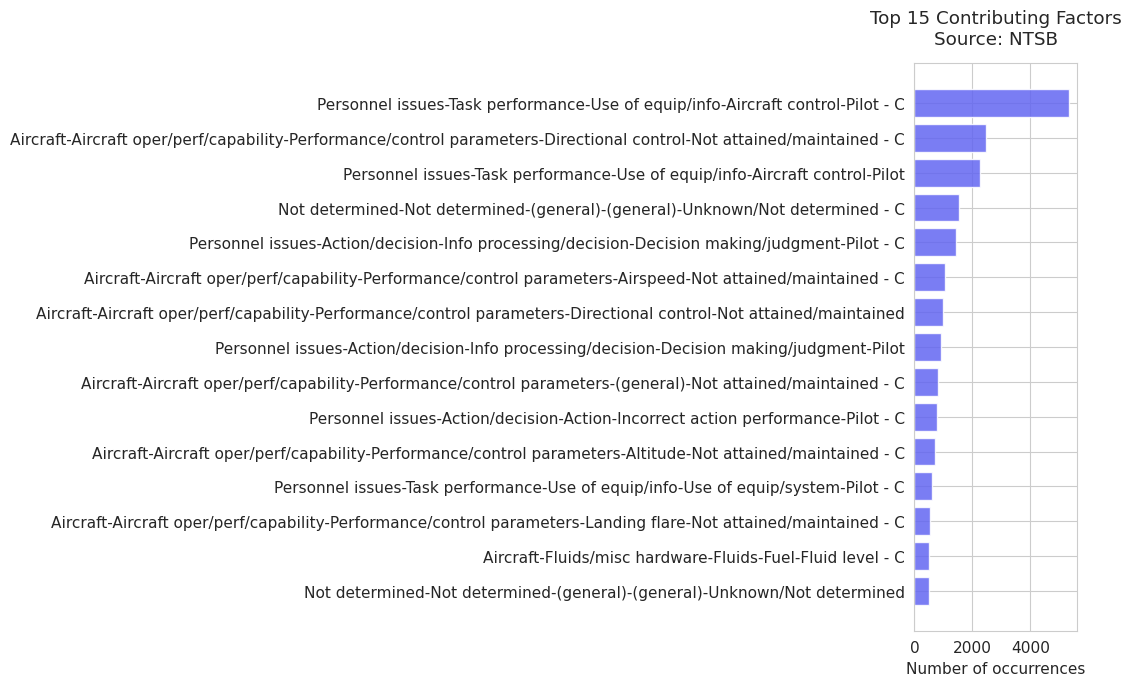

In [7]:
# Join findings back to filtered events to respect the 2008+ filter
findings_filtered = findings[findings["ev_id"].isin(events["ev_id"])]

top_findings = (
    findings_filtered[findings_filtered["finding_description"].notna()]
    .groupby("finding_description")
    .agg(count=("ev_id", "count"))
    .reset_index()
    .sort_values("count", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_findings["finding_description"], top_findings["count"],
        color="#6366F1", alpha=0.85)
ax.set_xlabel("Number of occurrences")
ax.set_title("Top 15 Contributing Factors\nSource: NTSB", pad=14)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../charts/q3_findings.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Human factors dominate the contributing factor list — decision-making,
situational awareness, and aircraft handling appear consistently near the top.
Mechanical factors are present but secondary.

**Caveat:** findings are assigned by NTSB investigators and reflect investigative
judgment, not objective measurement. The frequency of a finding code also reflects
how consistently investigators apply it across cases.

## Question 4 — Does pilot age correlate with accident severity?

We use pilot age as a crude proxy for experience. This is an intentional
simplification — a 60-year-old weekend pilot with 200 hours is less experienced
than a 30-year-old ATP with 8,000 hours. The relationship between age and
severity should be interpreted cautiously.

We show both KDE distributions (shape of age by severity) and boxplots
(median and spread) for a complete picture.

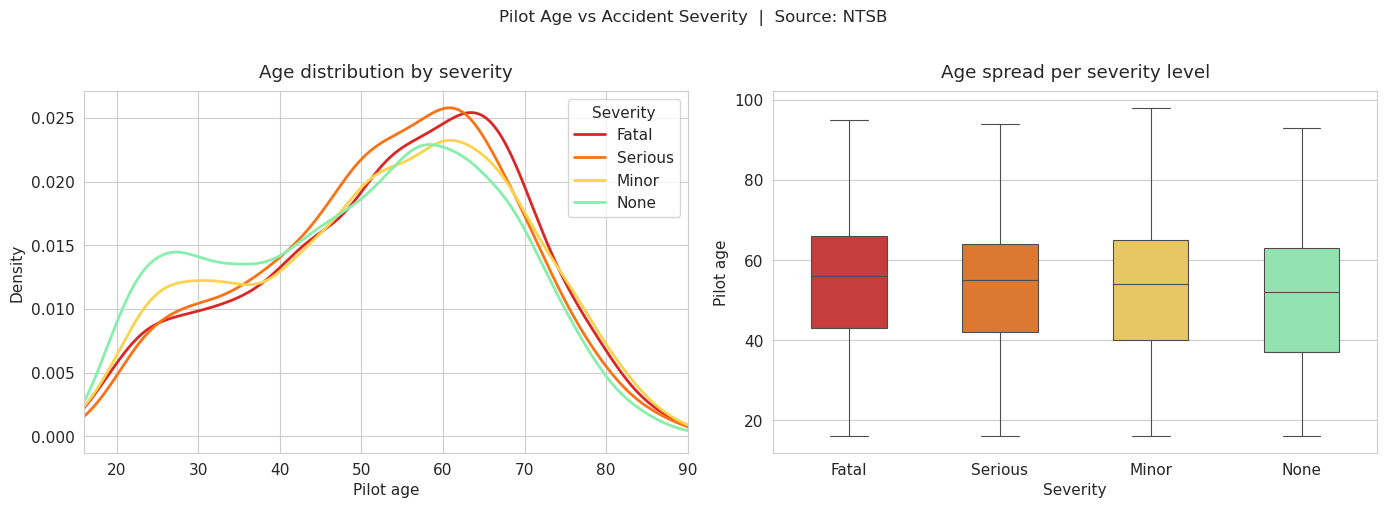

Median pilot age by severity:
severity_label
Fatal      56.0
Serious    55.0
Minor      54.0
None       52.0


In [8]:
injury_order  = ["FATL", "SERS", "MINR", "NONE"]
injury_labels = {"FATL": "Fatal", "SERS": "Serious", "MINR": "Minor", "NONE": "None"}
palette       = {"FATL": "#DC2626", "SERS": "#F97316", "MINR": "#FCD34D", "NONE": "#86EFAC"}

crew_clean = (
    crew[["ev_id", "crew_age"]]
    .assign(crew_age=lambda d: pd.to_numeric(d["crew_age"], errors="coerce"))
    .merge(events[["ev_id", "ev_highest_injury"]], on="ev_id", how="inner")
    .dropna(subset=["crew_age", "ev_highest_injury"])
    .query("crew_age >= 16 and crew_age <= 100")  # remove implausible values
)
crew_clean["severity_label"] = crew_clean["ev_highest_injury"].map(injury_labels)
order_labels = [injury_labels[k] for k in injury_order if injury_labels[k]
                in crew_clean["severity_label"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE
ax = axes[0]
for level in injury_order:
    subset = crew_clean[crew_clean["ev_highest_injury"] == level]["crew_age"]
    if len(subset) > 30:
        subset.plot.kde(ax=ax, label=injury_labels[level],
                        color=palette[level], linewidth=2)
ax.set_xlabel("Pilot age")
ax.set_ylabel("Density")
ax.set_xlim(16, 90)
ax.set_title("Age distribution by severity", pad=10)
ax.legend(title="Severity")

# Boxplot
ax = axes[1]
sns.boxplot(data=crew_clean, x="severity_label", y="crew_age",
            order=order_labels,
            palette={v: palette[k] for k, v in injury_labels.items()},
            width=0.5, linewidth=0.8, fliersize=2, ax=ax)
ax.set_xlabel("Severity")
ax.set_ylabel("Pilot age")
ax.set_title("Age spread per severity level", pad=10)

plt.suptitle("Pilot Age vs Accident Severity  |  Source: NTSB", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../charts/q4_age_severity.png", dpi=150, bbox_inches="tight")
plt.show()

print("Median pilot age by severity:")
print(crew_clean.groupby("severity_label")["crew_age"].median()
      .reindex(order_labels).round(1).to_string())

**Finding:** The age distributions across severity levels are broadly similar,
suggesting pilot age alone is a weak predictor of accident severity.
Any observed difference in medians should not be interpreted as causal —
aircraft type, operation type, and weather conditions are likely stronger
and confounding predictors.

## Question 5 — Are IMC accidents more lethal than VMC accidents?

`wx_cond_basic` classifies weather at the time of the accident into:
- **VMC** — Visual Meteorological Conditions (pilot navigates by sight)
- **IMC** — Instrument Meteorological Conditions (low visibility, clouds)

From an aeronautical standpoint, IMC is inherently higher risk for pilots
without instrument ratings — spatial disorientation and CFIT (Controlled
Flight Into Terrain) are leading causes of fatal IMC accidents.

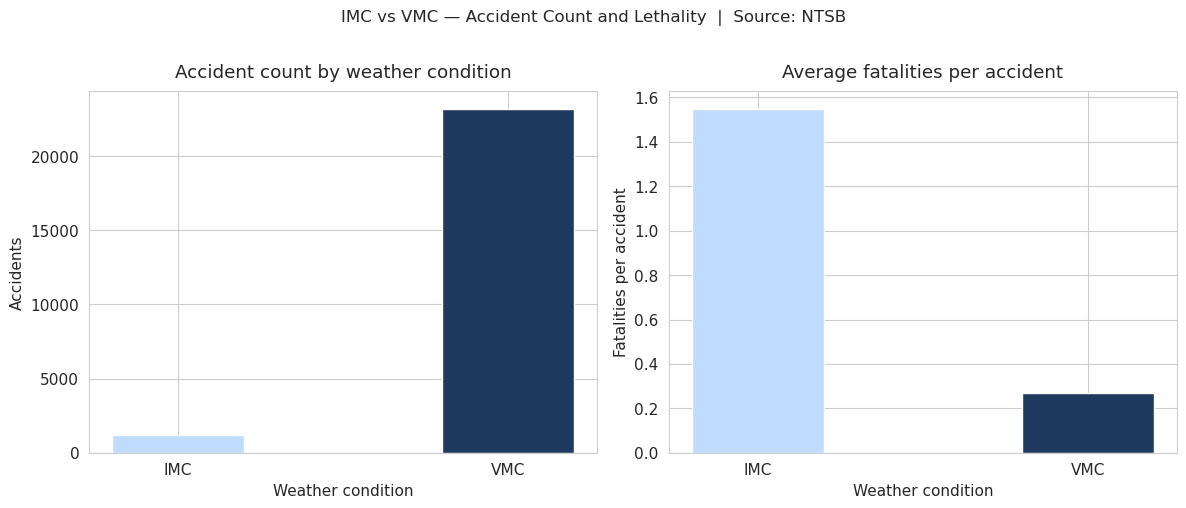

wx_cond_basic  accidents  fatalities  avg_fatalities
          IMC       1173        1822            1.55
          VMC      23199        6293            0.27


In [9]:
wx = (
    events[events["wx_cond_basic"].isin(["IMC", "VMC"])]
    .groupby("wx_cond_basic")
    .agg(accidents=("ev_id", "count"),
         fatalities=("inj_tot_f", "sum"),
         avg_fatalities=("inj_tot_f", "mean"))
    .round(2)
    .reset_index()
)
wx["avg_fatalities"] = (wx["fatalities"] / wx["accidents"]).round(2)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(wx["wx_cond_basic"], wx["accidents"],
            color=["#BFDBFE", "#1E3A5F"], width=0.4)
axes[0].set_title("Accident count by weather condition", pad=10)
axes[0].set_ylabel("Accidents")

axes[1].bar(wx["wx_cond_basic"], wx["avg_fatalities"],
            color=["#BFDBFE", "#1E3A5F"], width=0.4)
axes[1].set_title("Average fatalities per accident", pad=10)
axes[1].set_ylabel("Fatalities per accident")

for ax in axes:
    ax.set_xlabel("Weather condition")

plt.suptitle("IMC vs VMC — Accident Count and Lethality  |  Source: NTSB",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../charts/q5_imc_vmc.png", dpi=150, bbox_inches="tight")
plt.show()

print(wx[["wx_cond_basic", "accidents", "fatalities", "avg_fatalities"]].to_string(index=False))

**Finding:** VMC accidents are 20× more frequent — most general aviation
flying happens in visual conditions. However, IMC accidents average
**1.55 fatalities per event** compared to 0.27 for VMC — a 5.7× difference.

This aligns with known aeronautical risk factors: a VFR pilot who
inadvertently enters IMC typically has less than 3 minutes before losing
control due to spatial disorientation (the "graveyard spiral" scenario).
CFIT accidents — where a structurally intact aircraft flies into terrain —
are disproportionately associated with IMC.

## Geographic distribution

Heatmap of accident locations using decimal coordinates from the `events` table.
Density reflects absolute accident count, not accident rate — states with more
air traffic will naturally appear hotter.

In [10]:
coords = (
    events
    .dropna(subset=["dec_latitude", "dec_longitude"])
    .query("dec_latitude.between(15, 72) and dec_longitude.between(-180, -60)")
)

m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles="CartoDB positron")
HeatMap(coords[["dec_latitude", "dec_longitude"]].values.tolist(),
        radius=6, blur=8, max_zoom=13, min_opacity=0.3).add_to(m)

out = "../charts/map_accidents.html"
m.save(out)
print(f"Map saved — {len(coords):,} accidents plotted")
print(f"Open: {os.path.abspath(out)}")

Map saved — 24,341 accidents plotted
Open: /home/miguel/Projects/aviation-EDA/charts/map_accidents.html


## Summary of findings

In [11]:
summary = pd.DataFrame({
    "Question": [
        "1. Trend over time",
        "2. Phase of flight",
        "3. Contributing factors",
        "4. Pilot age vs severity",
        "5. IMC vs VMC lethality",
    ],
    "Finding": [
        "Sustained decline 2008-2019; COVID dip in 2020; post-2020 below historical baseline",
        "Uncontrolled descent most frequent and most lethal (avg 1.07 fatalities); landing accidents frequent but survivable (avg 0.01-0.02)",
        "Human factors dominate: decision-making, situational awareness, aircraft handling",
        "Age distributions broadly similar across severity — age alone is a weak predictor",
        "VMC 20x more frequent; IMC accidents average 1.55 fatalities vs 0.27 for VMC (5.7x difference)",
    ],
    "Caveat": [
        "No flight-hour denominator — absolute counts, not rates",
        "One accident can have multiple phase records; distinct ev_id used",
        "Finding codes reflect investigator judgment, not objective measurement",
        "Age ≠ experience; aircraft type and weather are likely stronger confounders",
        "IMC/VMC missing for some records; no instrument-rating data to control for",
    ]
})
display(summary)

,Question,Finding,Caveat
0,1. Trend over time,Sustained decline 2008-2019; COVID dip in 2020...,"No flight-hour denominator — absolute counts, ..."
1,2. Phase of flight,Uncontrolled descent most frequent and most le...,One accident can have multiple phase records; ...
2,3. Contributing factors,"Human factors dominate: decision-making, situa...","Finding codes reflect investigator judgment, n..."
3,4. Pilot age vs severity,Age distributions broadly similar across sever...,Age ≠ experience; aircraft type and weather ar...
4,5. IMC vs VMC lethality,VMC 20x more frequent; IMC accidents average 1...,IMC/VMC missing for some records; no instrumen...


## Limitations & scope

1. **No exposure denominator.** This analysis counts accidents, not accident
   rates. A state or phase with more accidents may simply have more flights.
   FAA ASIAS flight-hour data would be needed for true rate analysis.

2. **Accidents only.** The database captures events the NTSB investigated.
    Near-misses and incidents not reaching the reporting threshold are absent.

3. **IMC/VMC classification gaps.** Weather condition is missing for a share
   of records — if missingness correlates with severity, the IMC/VMC comparison
   is biased.

4. **Pilot age as experience proxy.** Total flight hours from the `flight_time`
   table would be a sharper measure. A follow-up analysis using actual hours
   is a natural extension of Question 4.

5. **Findings reflect investigative judgment.** Contributing factor codes are
   assigned by NTSB investigators and may reflect institutional conventions
   as much as objective causation.